# 15A — Thermodynamics (Bragg–Williams Approximation)

Computes finite-temperature sublattice occupancies using the Bragg–Williams approximation applied to ML formation energies. Produces the R-phase comparison with XRD data.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/R_structures.pkl` (available on Zenodo)
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/results/PREDICTION__R__*.csv`

## Outputs
- Thermodynamics figures in `Fe-Mo/graphs/`



In [1]:
import pandas as pd
from pycef.cef_minimization import *
import json
import os

In [2]:
from matplotlib.lines import Line2D

In [3]:
from Tools.DatasetTools.GeneralFeaturizer import cn_dict

/home/mariano/.local/micromamba/envs/datasets_ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
lattice_names = {
    'R' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$', '$f_8$'],
#    'R_10' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$ and $f_8$'],
#    'delta': ['$a_1$', '$a_2$', '$a_3$', '$a_4$', '$a_5$', '$a_6$', '$a_7$', '$a_8$', '$a_9$', '$a_{10}$', '$a_{11}$', '$a_{12}$', '$a_{13}$', '$a_{14}$'],
    'P': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$c_{10}$', '$d_1$', '$d_2$'],
    'M': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$d_1$', '$d_2$'],
    'C14': ['$f$', '$a$', '$h$' ],
    'mu': ['$a$', '$h$', '$c_1$', '$c_2$', '$c_3$'],
    'sigma': ['$a$', '$f$', '8$_i$', '8$_i\'$', '8$_j$']
}

In [5]:
multiplicities = {
    'R': [1,2,6,6,6,6,6,6,6,2,6],
#    'R_10':[1,2,6,6,6,6,6,6,6,8],
    'delta': 14*[4],
    'P': 10*[4]+[8,8],
    'M': 9*[4]+[8,8],
    'C14': [4, 2, 6],
    'mu': [1, 6, 2, 2, 2],
    'sigma': [2, 4, 8, 8, 8] # 12a 12b 15 16 14
} 

In [6]:
import matplotlib.pyplot as plt

In [7]:
MAG = 1
if MAG == 0:
    target_case = 'EF_nmhcp'
    query_mag = 'Mag == "NM"'
elif MAG == 1:
    target_case = 'EF_fmbcc'
    query_mag = 'Mag == "FM"'


In [8]:
#phases = ['R', 'R_10']#, 'P', 'M', 'delta']

In [9]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl').query(query_mag)

In [10]:
for phase, phasebs in BS.groupby('Phase'):
    break

In [11]:
phasebs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv2Mo_sv6.A15-BA.FM,bulk A15-BA.FM,14.757480 A,-10.202329,238.003165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,6,8,0.25,0.75,FM,A15,0.061044,0.061044,0.061044
Fe_pv6Mo_sv2.A15-AB.FM,bulk A15-AB.FM,12.624795 A,-8.867454,203.806345 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,6,2,8,0.75,0.25,FM,A15,0.057155,0.057155,0.057155
Mo_sv8.A15.FM,bulk A15.FM,16.077050 A,-10.839029,253.594611 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,0.00,1.00,FM,A15,0.093726,0.093726,0.093726


In [12]:
phases = ['R', 'P', 'M', 'delta']#, 'R_10']

In [13]:
end_members_atoms={}
for phase in phases : 
    end_members_atoms[phase] = pd.read_pickle(f'Fe-Mo/Atomsobjects/{phase.replace("_10","")}_structures.pkl')
#        'R_10': pd.read_pickle('Fe-Mo/Atomsobjects/R_structures.pkl')

In [14]:
for phase, phasebs in BS.groupby('Phase'):
    break

In [15]:
config = phasebs.index.str.split('.').map(lambda v: v[1])

In [16]:
phasebs['config'] = config

TODO: calculate CEF for laves, mu and sigma for comparison

In [17]:
end_member_compositions = {}

In [18]:
BS.query('Phase == "C14" and Mag == "NM"').query('abs(Fe_pv - 2/3)<0.1')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc


In [19]:
#ValidationBS.query('Phase == "R"').query('"AAAAAABAABB" in index')

In [20]:
BS.query('Phase == "C14" and '+query_mag).query('abs(Fe_pv - 2/3)<0.1')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8Mo_sv4.C14-BAA.FM,bulk C14-BAA.FM,12.225179 A,-9.163183,232.536327 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,4,12,0.666667,0.333333,FM,C14,-0.015446,-0.015446,-0.015446


In [21]:
#ValidationBS.query('abs(Fe_pv - 2/3) < 0.01')

In [22]:
def get_compositions(atoms):
    compo = atoms.symbols.formula.count()
    return {e: n/len(atoms)  for e, n in compo.items()}

In [23]:
end_member_compositions={}
for phase, phaseatoms in end_members_atoms.items():
    end_member_compositions[phase] = pd.DataFrame.from_dict(phaseatoms['atoms'].map(get_compositions).to_dict(), orient='index').fillna(0)
    end_member_compositions[phase].index = end_member_compositions[phase].index.str.split('.').map(lambda v: v[1]).str.replace(f'{phase}-', '')

In [24]:
end_member_energies = {}

In [25]:
phases

['R', 'P', 'M', 'delta']

In [26]:
for phase in phases: #, 'P', 'M', 'delta']:
    phase_predictions_file = f'Fe-Mo/results/PREDICTION__{phase.replace("_10", "")}__ACE_lmax=321_MAG={MAG}.csv'
    end_member_energies[phase] = pd.read_csv(phase_predictions_file, header=0, index_col=0)[f'{target_case}__ACE']
#    end_member_energies[phase] = pd.read_json(phase_predictions_file)
#    with open(phase_predictions_file, 'r') as f: #f'MoNi/results_predictions/{phase}_prediction.json', 'r') as f:
#        this_phase_prediction = json.load(f)
#    end_member_energies[phase] = pd.Series(this_phase_prediction)
#    end_member_energies[phase].name = 'EF'

In [27]:
end_member_energies['R']

Fe_pv53.R.NM                      0.040465
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.013584
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.045610
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.019295
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.034146
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.357100
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.429974
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.345845
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.393404
Mo_sv53.R.NM                      0.308818
Name: EF_fmbcc__ACE, Length: 2048, dtype: float64

In [28]:
for phase, phase_energies in end_member_energies.items():
    if phase not in multiplicities:
        continue
    Natoms = sum(multiplicities[phase])
    phase_energies.index = phase_energies.index.str.replace(f'Fe_pv{Natoms}.{phase}', f'Fe_pv{Natoms}.{"A"*len(multiplicities[phase])}')
    phase_energies.index = phase_energies.index.str.replace(f'Mo_sv{Natoms}.{phase}', f'Mo_sv{Natoms}.{"B"*len(multiplicities[phase])}')
    phase_energies.index = phase_energies.index.map(lambda i: i.split('.')[1].replace(f'{phase}-', ''))

In [29]:
def extract_config_label(idx, phase, n_sites):
    s = str(idx)
    token = f"{phase}-"

    # Preferred path for labels like: Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM
    if token in s:
        label = s.split(token, 1)[1].split('.', 1)[0]
    else:
        parts = s.split('.')

        # Fallback for labels like: Fe_pv12.C14.NM or Mo_sv12.C14.NM
        if len(parts) >= 2 and parts[1] == phase:
            head = parts[0]
            if head.startswith('Fe_pv') and 'Mo_sv' not in head:
                label = 'A' * n_sites
            elif head.startswith('Mo_sv') and 'Fe_pv' not in head:
                label = 'B' * n_sites
            else:
                label = s

        # Fallback for malformed labels like: Fe_pv30.sigma_Fe_pv.FM
        elif len(parts) >= 2 and parts[1].startswith(f"{phase}_"):
            suffix = parts[1][len(phase) + 1:]
            if suffix.startswith('Fe_pv'):
                label = 'A' * n_sites
            elif suffix.startswith('Mo_sv'):
                label = 'B' * n_sites
            else:
                label = s

        elif len(parts) >= 2 and '-' in parts[1]:
            # General fallback: take the part after '-' in the middle segment.
            label = parts[1].split('-', 1)[1]
        else:
            label = s

    # Some endpoints can appear as duplicated tags: AAA...-AAA... or BBB...-BBB...
    # Collapse only when all hyphen-separated chunks are exactly the same.
    chunks = [c for c in label.split('-') if c]
    if len(chunks) > 1 and len(set(chunks)) == 1:
        label = chunks[0]

    return label


# Populate missing phases from BS when available.
for phase, phasebs in BS.groupby('Phase'):
    if phase not in multiplicities:
        continue

    if phase not in end_member_compositions:
        end_member_compositions[phase] = phasebs[[ 'Fe_pv', 'Mo_sv' ]].rename(columns={'Fe_pv': 'Fe', 'Mo_sv': 'Mo'}).sort_values(by='Fe')

    if phase not in end_member_energies:
        end_member_energies[phase] = phasebs[target_case]


# Normalize all phases already present in either dictionary (including phases absent from BS, e.g. delta).
all_phases = set(end_member_compositions.keys()) | set(end_member_energies.keys())
for phase in all_phases:
    if phase not in multiplicities:
        continue

    n_sites = len(multiplicities[phase])

    if phase in end_member_compositions:
        end_member_compositions[phase].index = end_member_compositions[phase].index.map(lambda i: extract_config_label(i, phase, n_sites))

    if phase in end_member_energies:
        end_member_energies[phase].index = end_member_energies[phase].index.map(lambda i: extract_config_label(i, phase, n_sites))

    if phase in end_member_compositions and phase in end_member_energies:
        # Keep energies aligned to composition index order.
        # Drop duplicate labels that arise from index normalisation before reindexing
        _e = end_member_energies[phase]
        _e = _e[~_e.index.duplicated(keep="first")]
        end_member_energies[phase] = _e.reindex(end_member_compositions[phase].index)

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
if 'R_10' in end_member_energies:
    end_member_energies['R_10'] = end_member_energies['R_10'][~(end_member_energies['R_10'].index.str.endswith('AB') | end_member_energies['R_10'].index.str.endswith('BA'))]

In [ ]:
import re

In [ ]:
min_sample = end_member_energies['R'][end_member_compositions['R'].query('abs(Fe-2/3)<0.01 ').index].idxmin()

In [ ]:
def redefine_index(theindex):
    if theindex.endswith('AA'):
        return  re.sub('AA$', 'A', theindex)
    if theindex.endswith('BB'):
        return  re.sub('BB$', 'B', theindex)

In [ ]:
if 'R_10' in end_member_energies:
    end_member_energies['R_10'].index.map(redefine_index)

In [ ]:
if 'R_10' in end_member_energies:
    pd.concat([pd.Series(end_member_energies['R_10'].index.map(redefine_index)), pd.Series(end_member_energies['R_10'].index)], axis=1)

In [ ]:
if 'R_10' in end_member_energies:
    end_member_energies['R_10'].index = end_member_energies['R_10'].index.map(redefine_index)

In [ ]:
if 'R_10' in end_member_energies:
    end_member_energies['R_10']

# create per-phase dataset

In [ ]:
curated_end_members_energies = {}

In [ ]:
for phase, phaseenergies in end_member_energies.items():
    phaseenergies.index = phaseenergies.index.str.replace(f'{phase}-', '')

In [ ]:
multiplicities

{'R': [1, 2, 6, 6, 6, 6, 6, 6, 6, 2, 6],
 'delta': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
 'P': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8],
 'M': [4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8],
 'C14': [4, 2, 6],
 'mu': [1, 6, 2, 2, 2],
 'sigma': [2, 4, 8, 8, 8]}

In [ ]:
lattice_names.keys()

dict_keys(['R', 'P', 'M', 'C14', 'mu', 'sigma'])

In [ ]:
end_member_compositions['mu'].index.symmetric_difference(end_member_energies['mu'].index)

Index([], dtype='object')

In [49]:
DG = {}
for T in [1700]: #[1000, 1250, 1500, 1700, 2000]: #, 2000]:
    DG[T] = {}
    for phase, phaselattice in lattice_names.items():
        if '_10' in phase:
            continue
        print(T, phase)
        DG[T][phase] = {}
        Lattice = LatticeModel(phaselattice, multiplicities[phase])
        xa = np.linspace(0, 1, 10)
        for xA in xa:
            try:
                opt = CEF(latticemodel=Lattice, molar_frac={'A': xA, 'B': 1-xA}, endmember_energies=end_member_energies[phase], temp=T)
                DG[T][phase][xA] = opt.result['y_is']
                DG[T][phase][xA].update({'DG': opt.result['minimized_gibbs_energy (eV/atom)']})
                DG[T][phase][xA].update({'Mix': opt.result['gibbs_mixing (eV/atom)']})
            except KeyError as E:
                missing_key = str(E).strip("'")
                print(f"missing end-member key '{missing_key}' for xa={xA} at T={T} and phase={phase}")
            except Exception as E:
                print(f"could not solve for xa={xA} at T={T} and phase={phase}: {type(E).__name__}: {E}")
        DG[T][phase]= pd.DataFrame.from_dict(DG[T][phase], orient='index').fillna(0)


1700 R
1700 P
1700 M
1700 C14
1700 mu
missing end-member key 'AAABB' for xa=0.1111111111111111 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.2222222222222222 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.3333333333333333 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.4444444444444444 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.5555555555555556 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.6666666666666666 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.7777777777777777 at T=1700 and phase=mu
missing end-member key 'AAABB' for xa=0.8888888888888888 at T=1700 and phase=mu
1700 sigma
missing end-member key 'BBAAA' for xa=0.1111111111111111 at T=1700 and phase=sigma
missing end-member key 'BBAAA' for xa=0.2222222222222222 at T=1700 and phase=sigma
missing end-member key 'BBAAA' for xa=0.3333333333333333 at T=1700 and phase=sigma
missing end-member key 'BBAAA' for xa=0.4444444444444444 at T=

In [42]:
DG[1700]['R']['Mix']

0.000000    0.000000
0.111111   -0.040374
0.222222   -0.052890
0.333333   -0.048446
0.444444   -0.032894
0.555556   -0.031390
0.666667   -0.045545
0.777778   -0.049071
0.888889   -0.036785
1.000000    0.000000
Name: Mix, dtype: float64

In [43]:
DG[1700]['mu']#['Mix']

,B@$a$,B@$h$,B@$c_1$,B@$c_2$,B@$c_3$,DG,Mix,A@$a$,A@$h$,A@$c_1$,A@$c_2$,A@$c_3$
0.0,1.0,1.0,1.0,1.0,1.0,0.308762,0.0,0.0,0.0,0.0,0.0,0.0
1.0,0.0,0.0,0.0,0.0,0.0,0.119784,0.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
DG[1700]['C14']#['Mix']

,B@$f$,B@$a$,B@$h$,DG,Mix,A@$f$,A@$a$,A@$h$
0.000000,1.000000,1.000000,1.000000,0.380763,0.000000,0.000000,0.000000,0.000000
0.111111,0.998998,0.866253,0.823028,0.266566,-0.044183,0.001002,0.133747,0.176972
0.222222,0.998997,0.747868,0.640269,0.179419,-0.062024,0.001003,0.252132,0.359731
0.333333,0.998961,0.627356,0.458241,0.106474,-0.067038,0.001039,0.372644,0.541759
0.444444,0.998488,0.481163,0.285065,0.046391,-0.061238,0.001512,0.518837,0.714935
0.555556,0.996818,0.281003,0.130676,0.001068,-0.043945,0.003182,0.718997,0.869324
0.666667,0.959447,0.038680,0.014142,-0.019496,-0.017724,0.040553,0.961320,0.985858
0.777778,0.662151,0.004485,0.001515,0.008204,-0.032765,0.337849,0.995515,0.998485
0.888889,0.329282,0.003232,0.001623,0.063386,-0.032357,0.670718,0.996768,0.998377
1.000000,0.000000,0.000000,0.000000,0.149237,0.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_38209/997880593.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


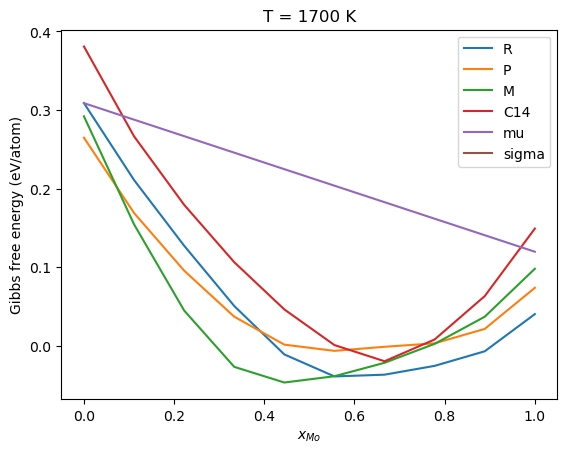

In [45]:
for T, dataT in DG.items():
    if len(dataT) == 0:
        continue
    fig, ax = plt.subplots()
    for phase, thedgs in dataT.items():
        if len(thedgs) == 0:
            continue
        ax.plot(thedgs.index, thedgs['DG'], label=phase)
    ax.legend()
    ax.set_xlabel('$x_{Mo}$')
    ax.set_ylabel('Gibbs free energy (eV/atom)')
    ax.set_title(f'T = {T} K')
    fig.show()

In [49]:
#from prototypemixer.PrototypeTCPs import cn_dict

In [50]:
#unique_cn, indexes = np.unique(cn_dict['P'], return_index=True)

In [51]:
# np.array( cn_dict['P'] )[np.sort(indexes)]

In [52]:
colors={
    '12': 'r',
    '14': 'b',
    '15': 'g',
    '16':  'k',
}

In [53]:
def get_line_color(CN: str):
    for cn, c in colors.items():
        if cn in CN:
            return c
    return 'grey'

In [54]:
#markers = ["1", "2", "3", "4",   0,   1,   2,   3,  4,  5,   6,   7,   8, 'd']
markers = ['>', 'v', '^', '>', 'p', 's', 'P', '*','D','X', 'd', 4, 5, 6]

In [55]:
cn_dict['R_10'] = [z.replace('16a', '16').replace('16b','16') for z in cn_dict['R']]

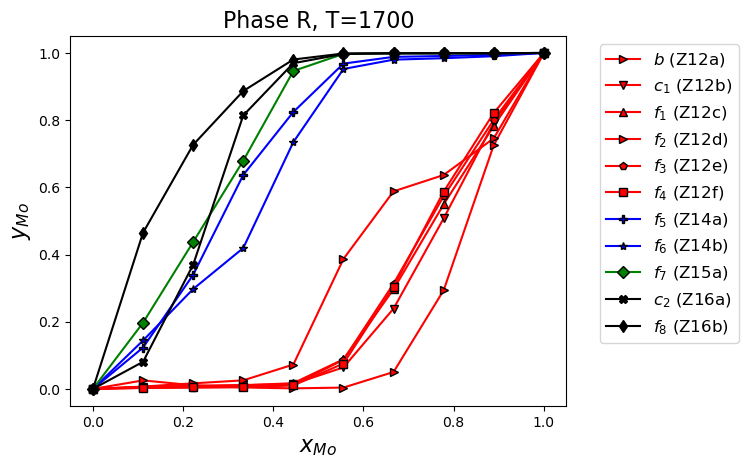

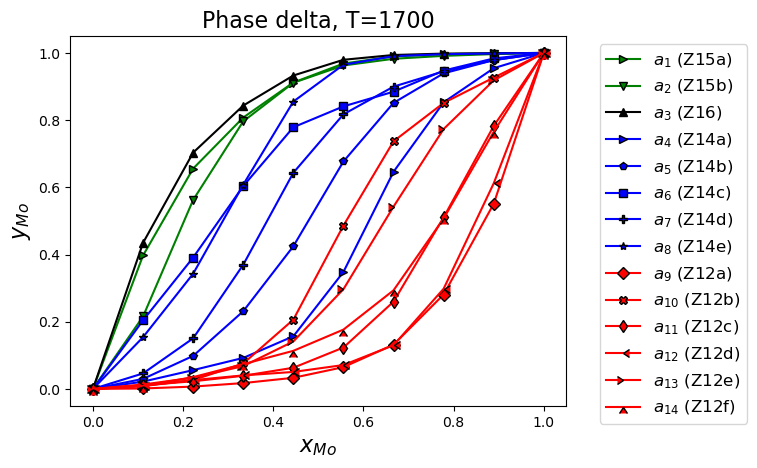

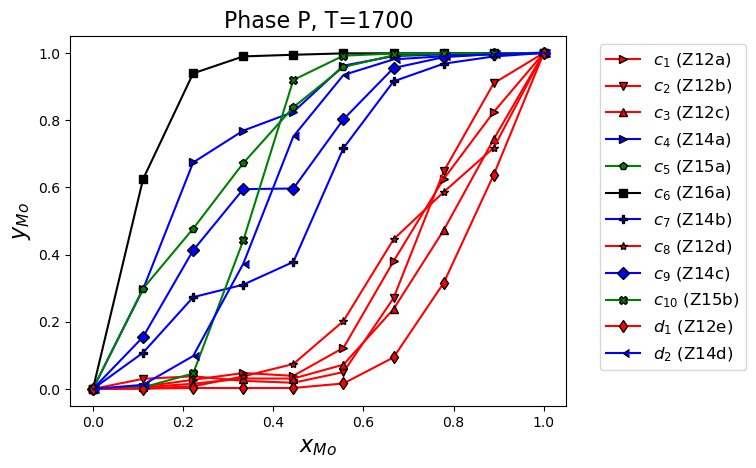

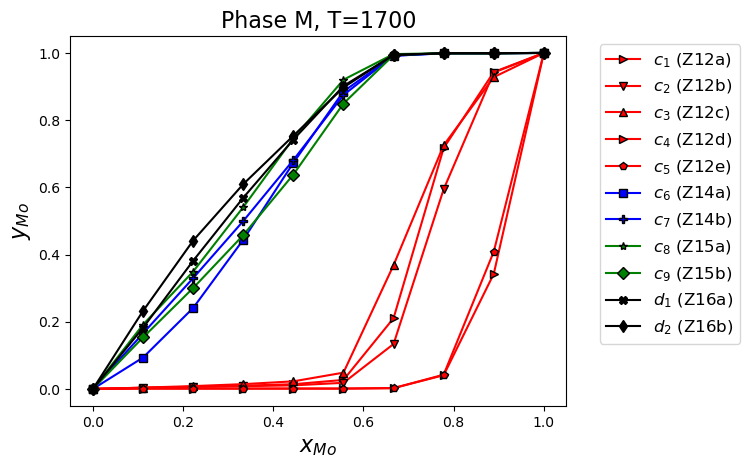

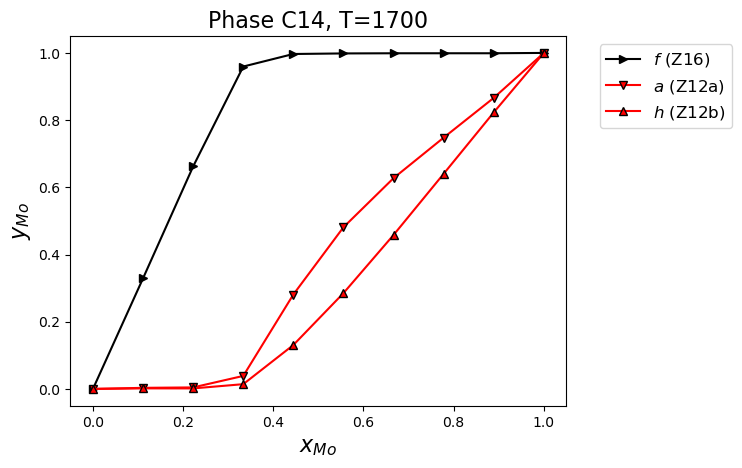

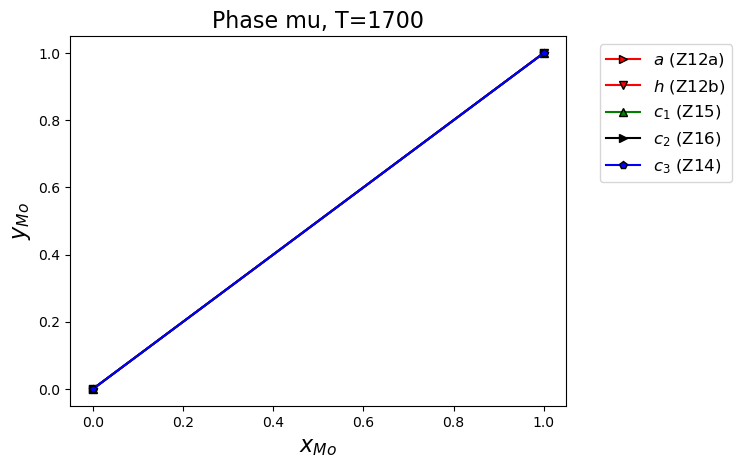

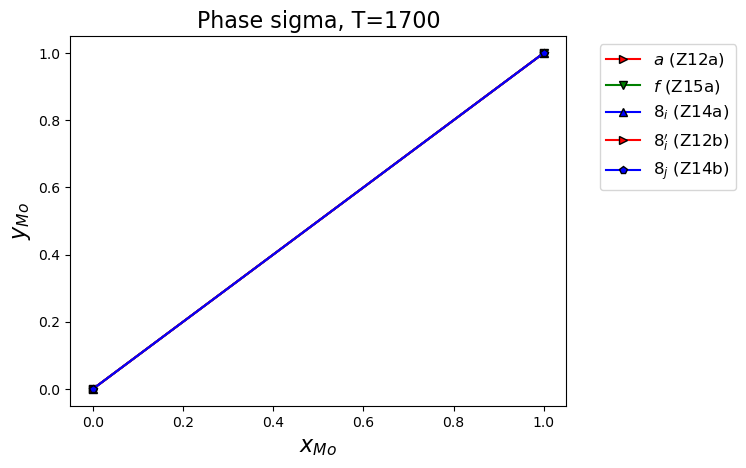

In [58]:
for T, phase_dg in DG.items():
    for phase, dg in phase_dg.items():
        sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
        unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
        fig, ax = plt.subplots()
        for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
            thisc = get_line_color(unique_cns[i])
            ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})', markeredgecolor = 'k')
        ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
        ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        ax.set_title(f'Phase {phase}, T={T}', fontsize=16)

In [80]:
phase_dg.keys()

dict_keys(['R', 'C14', 'mu'])

In [81]:
for T, phase_dg in DG.items():
    phase = 'R'
    phase_merge = 'R_10'
    dg = phase_dg[phase]
    if 'R_10' not in phase_dg:
        continue
    dgmix = phase_dg['R_10']
    sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
    unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
    fig, ax = plt.subplots()
    for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
        thisc = get_line_color(unique_cns[i])
        ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})')
    for i, (colname, coldata) in enumerate( dgmix.filter(regex='A').items()):
        thisc = get_line_color(unique_cns[i])
        ax.plot(1-coldata.index, 1-coldata.values, linestyle = '--', color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})') # marker = markers[i],
    ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
    ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    ax.set_title(f'Phase {phase}, T={T}', fontsize=16)

# load experimental data

In [82]:
experimentaldata = pd.read_csv('Fe-Mo/ExperimentalData/CrWCo.csv', header=[0], index_col = 0)
experimental_cn = {  'D1': '16','D2':'16','C1':'15','B1':'14','B2':'14','A1':'12','A2':'12','A3':'12','A4':'12','A5':'12','A6':'12'}

In [83]:
experimentaldata.columns

Index(['D1', 'D2', 'C1', 'B1', 'B2', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6'], dtype='object')

In [84]:
experimentaldata_sites_rename={'D1': '$c_2$', 'D2': '$f_8$', 'C1': '$f_7$', 'B1': '$f_5$', 'B2': '$f_6$', 'A1': '$b$', 'A2': '$c_1$', 'A3': '$f_1$', 'A4': '$f_2$', 'A5': '$f_3$', 'A6':'$f_4$'}

In [85]:
experimentaldata.rename(columns=experimentaldata_sites_rename, inplace=True)

In [86]:
experimentaldata

,$c_2$,$f_8$,$f_7$,$f_5$,$f_6$,$b$,$c_1$,$f_1$,$f_2$,$f_3$,$f_4$
composition,,,,,,,,,,,
0.27958,1.00000,1.00000,0.46667,0.37849,0.32258,0.000000,0.000000,0.000000,0.000000,0,0
0.30968,1.00000,0.97204,0.50968,0.42151,0.45806,0.060215,0.049462,0.030108,0.017204,0,0
0.31958,1.00000,1.00000,0.55054,0.41935,0.41935,0.079570,0.079570,0.000000,0.000000,0,0
0.33465,0.93118,0.93118,0.64086,0.49892,0.50968,0.141940,0.040860,0.019355,0.004301,0,0
0.34988,1.00000,0.99570,0.69032,0.55054,0.51828,0.030108,0.019355,0.000000,0.000000,0,0
0.35485,0.99785,0.80860,0.76129,0.51183,0.62796,0.049462,0.040860,0.006452,0.000000,0,0
0.37978,0.99800,0.99800,0.75914,0.62366,0.52903,0.111830,0.107530,0.000000,0.000000,0,0


# compare experimental data to prediction

In [87]:
figw, figh = plt.rcParams['figure.figsize']

In [88]:
plt.rc('text', usetex=True)

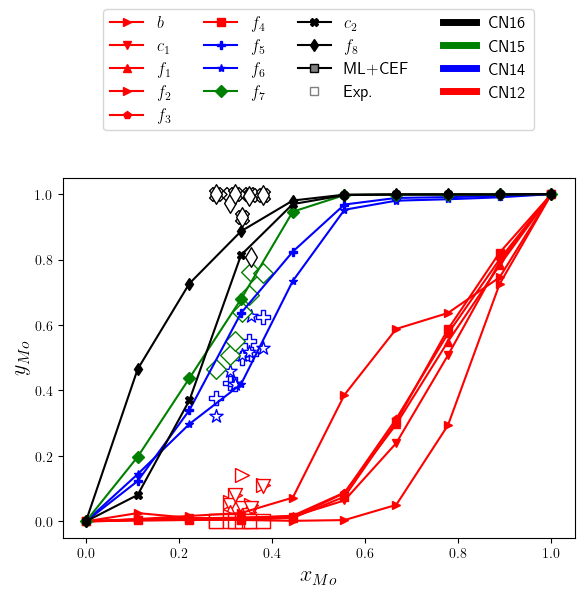

In [89]:
fig = plt.figure(figsize=(figw, 3*figh/2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.5])
#for site, sitedata in experimentaldata.items():
#    ax.scatter(sitedata.index, sitedata.values, c=colors[experimental_cn[site]])
phase='R'
T=1700
dg=DG[T][phase]
sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
    thisc = get_line_color(unique_cns[i])
    ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")}')#    ({unique_cns[i]})')
    ax.scatter(experimentaldata.index, experimentaldata[colname.replace('A@', '')], marker = markers[i], s = 100, facecolor='w', edgecolor=thisc, linewidth=1)
#for i, (colname, coldata) in enumerate( dgmix.filter(regex='A').items()):
#    thisc = get_line_color(unique_cns[i])
#    ax.plot(1-coldata.index, 1-coldata.values, linestyle = '--', color=thisc)#, label = f'{colname.replace("A@","")} ({unique_cns[i]})') # marker = markers[i],
handles, labels = ax.get_legend_handles_labels()
#handles.append(Line2D([],[],linestyle='--')),
handles.append(Line2D([],[],marker='s', markerfacecolor = 'grey', color = 'k'))
handles.append(Line2D([],[],marker='s', markerfacecolor = 'white', color='grey', linewidth=5, linestyle='',))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='k', label = 'CN16'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='g', label = 'CN15'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='b', label = 'CN14'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='r', label = 'CN12'))

#labels.append('10 sublattice model')
labels.append('ML+CEF')
labels.append('Exp.')
labels.append('CN16')
labels.append('CN15')
labels.append('CN14')
labels.append('CN12')
ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.3), loc='center', fontsize=12, ncols = 4)
#ax.legend(handles, labels, fontsize=12, ncols = 4)
# ax.set_title(f'Phase {phase}, T={T}', fontsize=16)
fig.savefig('Fe-Mo/graphs/SiteOccupancyExperimental_vs_Predictions.pdf')


In [56]:
labels

['$b$ (Z12a)',
 '$c_1$ (Z12b)',
 '$f_1$ (Z12c)',
 '$f_2$ (Z12d)',
 '$f_3$ (Z12e)',
 '$f_4$ (Z12f)',
 '$f_5$ (Z14a)',
 '$f_6$ (Z14b)',
 '$f_7$ (Z15a)',
 '$c_2$ (Z16a)',
 '$f_8$ (Z16b)',
 '10 sublattice model',
 'prediction from ML+CEF',
 'Experimental results']